In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from pyexpat import model

from plotly.graph_objs.layout import legend
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Библ загруз")

Библ загруз


In [5]:
df = pd.read_parquet('../data/processed/tender_data_v2.parquet')

print (f"Размер датасета: {df.shape}")
print (f"Колонки: {df.columns.tolist()}")
print (f"Размер датасета is train:")
print (df['is_train'].value_counts())

Размер датасета: (4519, 27)
Колонки: ['start_price', 'log_start_price', 'tender_security', 'security_ratio', 'has_security', 'advance_money_pct', 'has_advance', 'year', 'month', 'quarter', 'day_of_week', 'day_of_month', 'is_end_of_quarter', 'is_end_of_year', 'customer_total_tenders', 'customer_success_rate', 'region_total_tenders', 'region_success_rate', 'procedure_success_rate', 'procedure', 'legislation', 'for_small_business', 'customer_region_code', 'customer_region', 'y_success', 'publication_date', 'is_train']
Размер датасета is train:
is_train
True     3615
False     904
Name: count, dtype: int64


In [6]:
import sys
sys.path.append('..')

from src.features import FEATURE_COLS,CAT_FEATURES, TARGET

print (f"Всего признаков: {len(FEATURE_COLS)}")
print (f"Категориальных: {len(CAT_FEATURES)}")
print (f"Целевая: {TARGET}")
print (f"/nРазмер датасета:/n {CAT_FEATURES}")

Всего признаков: 24
Категориальных: 5
Целевая: y_success
/nРазмер датасета:/n ['procedure', 'legislation', 'for_small_business', 'customer_region_code', 'customer_region']


In [7]:
X_train =df[df['is_train']][FEATURE_COLS]
y_train =df[df['is_train']][TARGET]

X_test =df[~df['is_train']][FEATURE_COLS]
y_test =df[~df['is_train']][TARGET]

print(f"Train: {X_train.shape[0]:,} строк")
print(f"Test: {X_test.shape[0]:,} строк")

print(f"Баланс классов train: {y_train.mean():.3f}")
print(f"Баланс классов test: {y_test.mean():.3f}")

Train: 3,615 строк
Test: 904 строк
Баланс классов train: 0.338
Баланс классов test: 0.407


In [8]:
train_dates = df[df['is_train']]['publication_date']
test_dates = df[~df['is_train']]['publication_date']

assert train_dates.max() < test_dates.min(), "train пересекается с test по вермени"

print(f"Train: {train_dates.min()} -> {train_dates.max()}")
print(f"Test: {test_dates.min()} -> {test_dates.max()}")
print("Время в норме")

Train: 2017-11-22 11:56:21 -> 2022-10-13 16:49:52
Test: 2022-10-13 17:53:09 -> 2023-04-24 11:24:08
Время в норме


In [9]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=CAT_FEATURES
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=CAT_FEATURES
)

print(f"Train pool: {train_pool.shape}")
print(f"Test pool: {test_pool.shape}")

Train pool: (3615, 24)
Test pool: (904, 24)


**Создание модели**

In [10]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)

In [11]:
model.fit(
    train_pool,
    eval_set=test_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6597938	best: 0.6597938 (0)	total: 217ms	remaining: 1m 48s
100:	test: 0.6932085	best: 0.6966078 (82)	total: 6.04s	remaining: 23.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6966078237
bestIteration = 82

Shrink model to first 83 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

Первый результат:
bestTest = 0.6966078237
bestIteration = 82

In [12]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
}
print("Метрики base model а тесте:")
print("-"*40)
for name, value in metrics.items():
    print(f"{name:12s}: {value:.3f}")

Метрики base model а тесте:
----------------------------------------
Accuracy    : 0.670
Precision   : 0.662
Recall      : 0.389
F1          : 0.490
AUC-ROC     : 0.697


### Результаты baseline

| Метрика | Значение |
|---|----------|
| Accuracy  | 0.670    |
| Precision | 0.662    |
| Recall    | 0.389    |
| F1        | 0.490    |
| AUC-ROC   | 0.697    |

Лучшая итерация: 82 из 500

True Negative (правило не состоится): 463
False Positive (ощибочно состоится): 73
False Negative (ощибочно не состоится): 225
True Positive (правило состоится): 143


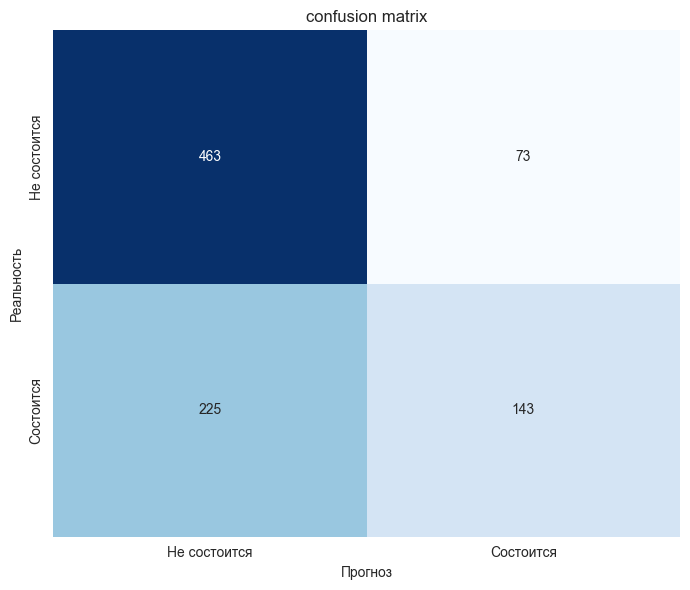

In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['Не состоится', 'Состоится'],
            yticklabels=['Не состоится', 'Состоится'])
ax.set_xlabel('Прогноз')
ax.set_ylabel('Реальность')
ax.set_title('confusion matrix')

tn, fp, fn, tp = cm.ravel()
print(f"True Negative (правило не состоится): {tn}")
print(f"False Positive (ощибочно состоится): {fp}")
print(f"False Negative (ощибочно не состоится): {fn}")
print(f"True Positive (правило состоится): {tp}")

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_baseli.png', dpi=150, bbox_inches='tight')
plt.show()

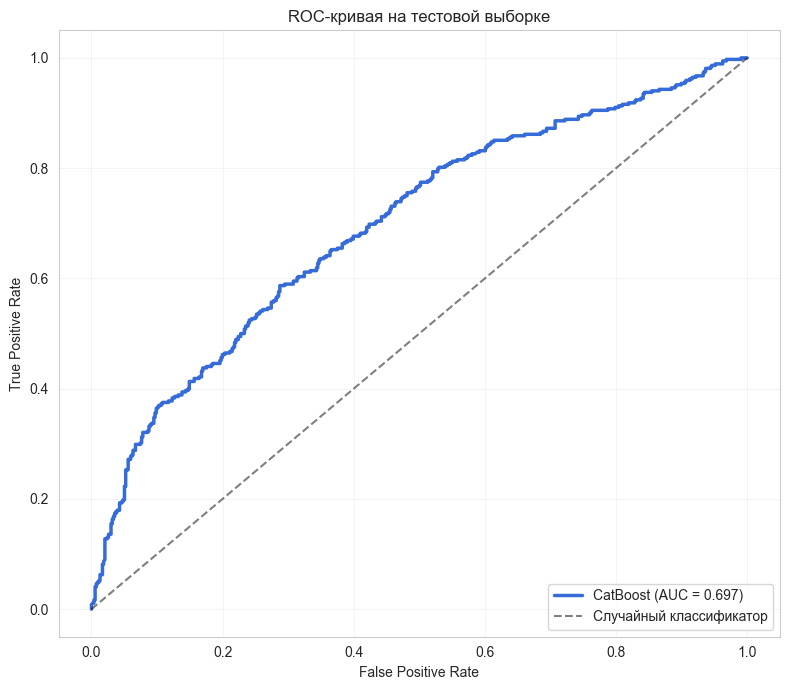

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, linewidth=2.5, label=f'CatBoost (AUC = {metrics["AUC-ROC"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный классификатор')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая на тестовой выборке')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
importance = model.get_feature_importance(prettified=True)
importance.columns = ['feature', 'importance']

# Топ-20
top_n = min(20, len(importance))
top_features = importance.head(top_n)

print(f"Топ-{top_n} важнейших признаков:")
print(top_features.to_string(index=False))

Топ-20 важнейших признаков:
               feature  importance
             procedure   18.606839
 customer_success_rate   16.927857
  customer_region_code   11.728858
procedure_success_rate    8.056545
customer_total_tenders    7.310523
   region_success_rate    6.251838
                  year    3.692845
           start_price    3.670754
     advance_money_pct    3.558669
          day_of_month    3.153876
       tender_security    3.043102
  region_total_tenders    2.863401
        security_ratio    2.407234
               quarter    2.127081
           day_of_week    1.585381
       log_start_price    1.574056
                 month    1.337843
       customer_region    0.585815
     is_end_of_quarter    0.516895
          has_security    0.444160


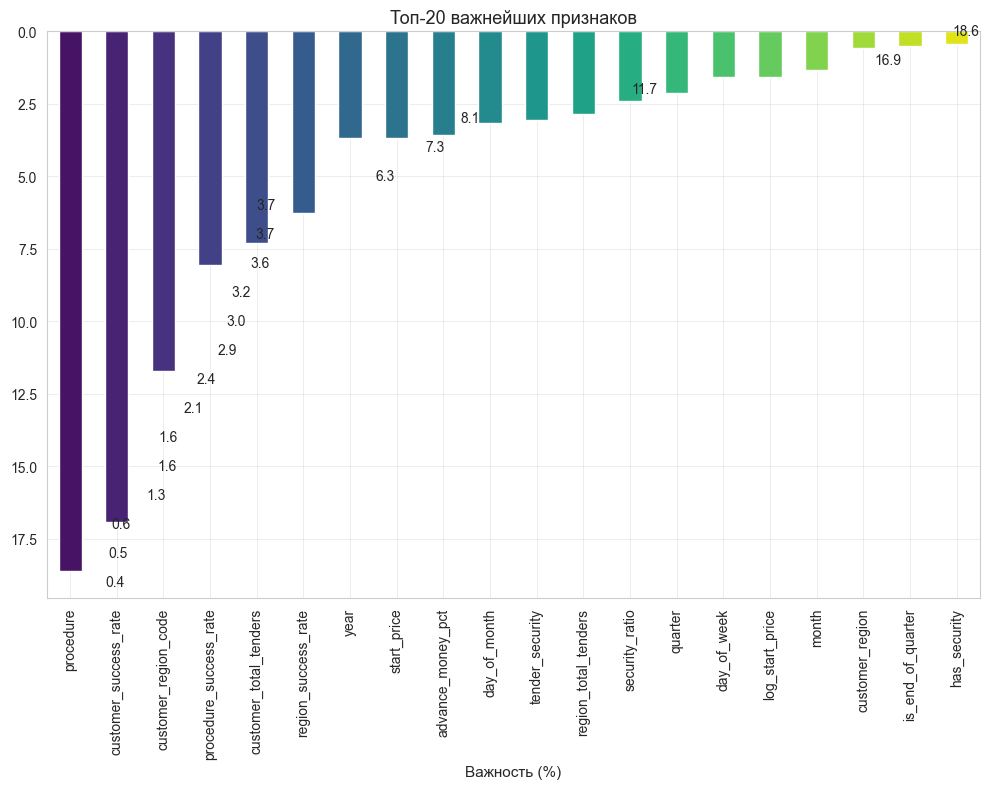

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('viridis', n_colors=top_n)

top_features.plot(
    x='feature', y='importance', kind='bar', ax=ax, color=colors,legend=False
)

ax.set_xlabel('Важность (%)', fontsize=11)
ax.set_ylabel('')
ax.set_title(f'Топ-{top_n} важнейших признаков', fontsize=13)
ax.invert_yaxis()

for i, v in enumerate(top_features['importance']):
    ax.text(v+0.3, i, f'{v:.1f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('../reports/feature_importance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Лучший порог по F1: 0.283
F1 при этом пороге: 0.6230
Precision: 0.5095
Recall:    0.8016


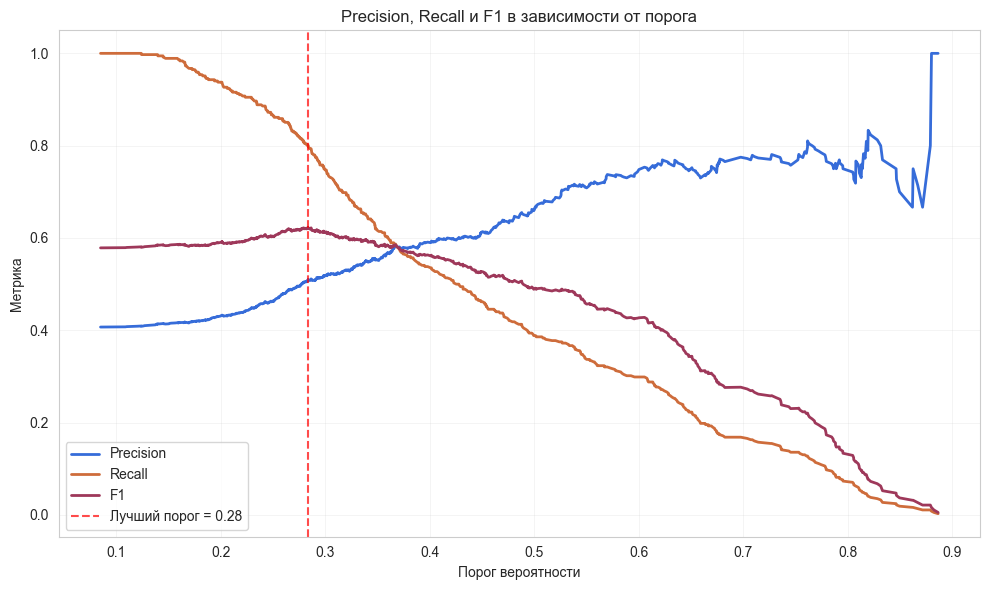

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# Лучший порог по F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Лучший порог по F1: {best_threshold:.3f}")
print(f"F1 при этом пороге: {best_f1:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")

# Графики
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
ax.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
ax.plot(thresholds, f1_scores[:-1], label='F1', linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.7, label=f'Лучший порог = {best_threshold:.2f}')
ax.set_xlabel('Порог вероятности')
ax.set_ylabel('Метрика')
ax.set_title('Precision, Recall и F1 в зависимости от порога')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/threshold_analysis_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import os
os.makedirs('../models', exist_ok=True)

# Сохраняем модель в нативном формате CatBoost
model.save_model('../models/catboost_baseline.cbm')

# Также сохраняем метрики в текстовый файл
with open('../models/baseline_metrics.txt', 'w', encoding='utf-8') as f:
    f.write(f"Baseline модель CatBoost\n")
    f.write(f"Дата обучения: {pd.Timestamp.now()}\n")
    f.write(f"Признаков: {len(FEATURE_COLS)}\n")
    f.write(f"Категориальных: {len(CAT_FEATURES)}\n")
    f.write(f"Train: {X_train.shape[0]:,} строк\n")
    f.write(f"Test:  {X_test.shape[0]:,} строк\n")
    f.write(f"\n--- Метрики на test ---\n")
    for name, value in metrics.items():
        f.write(f"{name:12s}: {value:.4f}\n")
    f.write(f"\nЛучший порог по F1: {best_threshold:.3f}\n")
    f.write(f"F1 при этом пороге: {best_f1:.4f}\n")

print("Модель сохранена: models/catboost_baseline.cbm")
print("Метрики сохранены: models/baseline_metrics.txt")

Модель сохранена: models/catboost_baseline.cbm
Метрики сохранены: models/baseline_metrics.txt
